# 1. Analisis Exploratorio de Datos (EDA)

**Proyecto 1: Competencia de Modelacion - Deep Learning (CC3092)**

Este notebook presenta la fase completa de analisis exploratorio para el conjunto de datos de viviendas (Ames Housing Dataset). Se analizan distribuciones, variables numericas y categoricas, valores nulos, atipicos, y se fundamentan las decisiones de preprocesamiento.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline


## 1.1 Carga del Dataset y Dimensiones Iniciales


In [2]:
train_df = pd.read_csv('../data/train.csv')
print(f'Dimensiones del conjunto de entrenamiento: {train_df.shape[0]} filas x {train_df.shape[1]} columnas')
train_df.head()


Dimensiones del conjunto de entrenamiento: 1168 filas x 81 columnas


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


## 1.2 Inspeccion de Tipos de Variables


In [3]:
num_vars = train_df.select_dtypes(include=[np.number]).columns.tolist()
cat_vars = train_df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f'Numero de variables numericas: {len(num_vars)}')
print(f'Numero de variables categoricas: {len(cat_vars)}')


Numero de variables numericas: 38
Numero de variables categoricas: 43


## 1.3 Distribucion de la Variable Objetivo (`SalePrice`)

Examinamos la asimetria de la variable objetivo y la necesidad de aplicar una transformacion logaritmica $\log(1 + y)$.


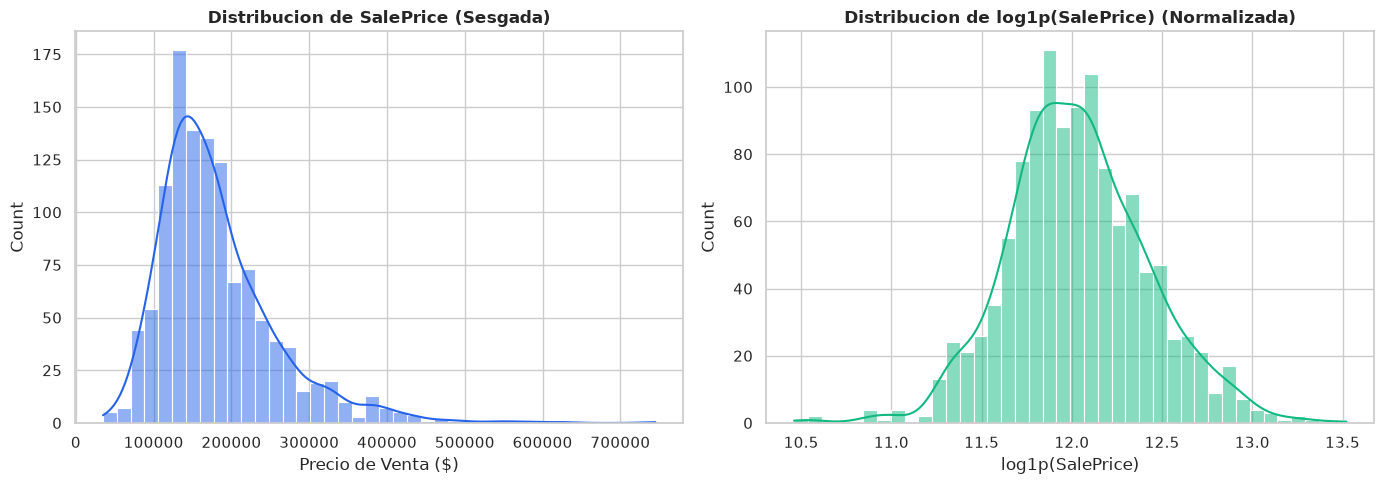

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_df['SalePrice'], kde=True, ax=axes[0], color='#2563EB', bins=40)
axes[0].set_title('Distribucion de SalePrice (Sesgada)', fontweight='bold')
axes[0].set_xlabel('Precio de Venta ($)')

sns.histplot(np.log1p(train_df['SalePrice']), kde=True, ax=axes[1], color='#10B981', bins=40)
axes[1].set_title('Distribucion de log1p(SalePrice) (Normalizada)', fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)')
plt.tight_layout()
plt.show()


## 1.4 Analisis de Valores Nulos e Inconsistencias


In [5]:
null_counts = train_df.isnull().sum()
null_percent = (null_counts / len(train_df)) * 100
null_summary = pd.DataFrame({'Valores_Faltantes': null_counts, 'Porcentaje (%)': null_percent})
null_summary = null_summary[null_summary['Valores_Faltantes'] > 0].sort_values(by='Porcentaje (%)', ascending=False)
print('Resumen de columnas con valores faltantes:')
null_summary


Resumen de columnas con valores faltantes:


,Valores_Faltantes,Porcentaje (%)
PoolQC,1162,99.486301
MiscFeature,1122,96.061644
Alley,1094,93.664384
Fence,935,80.051370
MasVnrType,683,58.476027
FireplaceQu,547,46.832192
LotFrontage,217,18.578767
GarageType,64,5.479452
GarageYrBlt,64,5.479452
GarageFinish,64,5.479452


## 1.5 Correlaciones con la Variable Objetivo


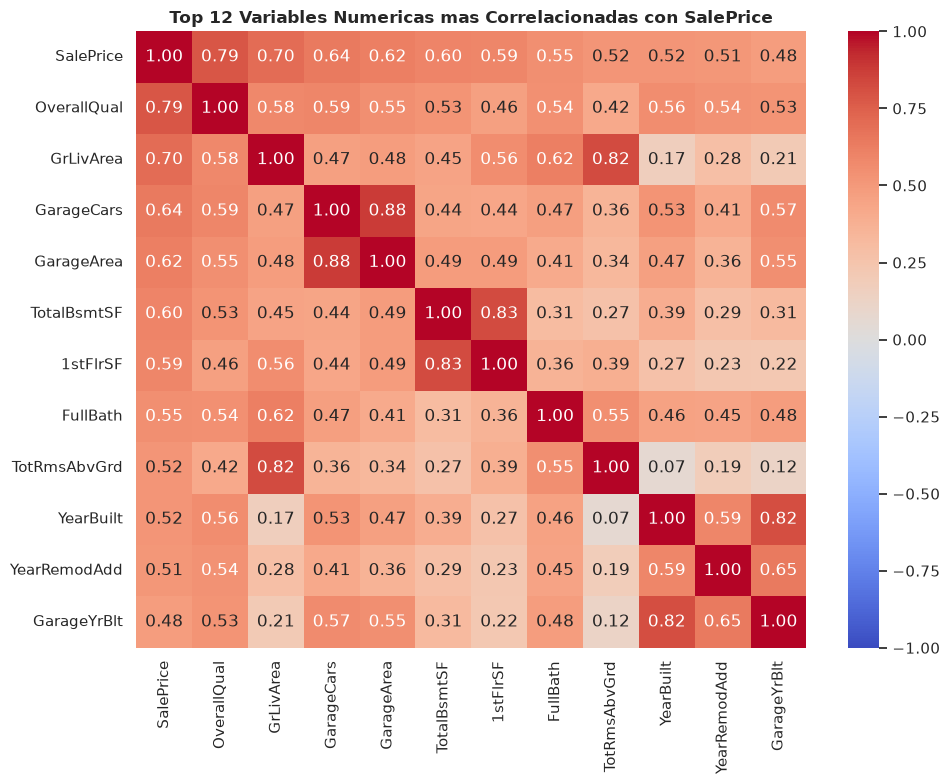

In [6]:
corr = train_df[num_vars].corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(train_df[top_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top 12 Variables Numericas mas Correlacionadas con SalePrice', fontweight='bold')
plt.tight_layout()
plt.show()


## 1.6 Conclusiones y Decisiones de Preprocesamiento Derivadas del EDA

1. **Transformacion de Variable Objetivo**: Aplicar `log1p(SalePrice)` para estabilizar la varianza del modelo MLP.
2. **Tratamiento de Nulos Dominiales**: Imputar `NA` como categoria `'None'` en caracteristicas donde representa la ausencia del elemento (Alley, Bsmt, Garage, Fireplace, Pool, Fence).
3. **Imputacion de LotFrontage**: Mediana segmentada por vecindario (`Neighborhood`).
4. **Ingenieria de Caracteristicas**: `TotalSF` (suma de sotano y pisos), `TotalBath`, edades de casa/garaje, terminos de interaccion de calidad.
5. **Codificacion Ordinal & Nominal**: Mapeo ordinal explicito para calificaciones (`Ex`, `Gd`, `TA`, `Fa`, `Po`) y One-Hot Encoding para nominales.
